# EDA 


## 1. Librerias

In [1]:
import pandas as pd
import numpy as np
import pyod

In [2]:
# Traemos dos datas ya que la de harvard dataverse tiene menos filas y hay varias distribuciones y parece que hay datos diferentes
data_survey = pd.read_csv("survey.csv")
data_purchases = pd.read_csv("amazon-purchases.csv")
data_survey2 = pd.read_csv("survey2.csv")

In [3]:
data_survey.head()

,Duration (in seconds),RecordedDate,ResponseId,Q-prolific-mturk,q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,...,Q-data-value-any_1_TEXT,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society,Q-attn-check,showdata,incentive,connect
0,332,9/21/2022 10:00:17,R_1ou69fj4DQGsVcp,NaN,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,...,NaN,No,No,No,No,No,"Yes,No,I don't know",False,bonus-50,NaN
1,488,9/21/2022 10:02:24,R_24dboHVOzohx1kw,NaN,25 - 34 years,No,White or Caucasian,Bachelor's degree,"$25,000 - $49,999",Male,...,NaN,Yes if I get part of the profit,Yes,No,Yes,Yes,"Yes,No,I don't know",False,bonus-05,NaN
2,309,9/21/2022 10:10:47,R_2UbJL30HRjK1sdD,NaN,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-05,NaN
3,339,9/21/2022 10:13:03,R_UPXamGKtmf4RVIZ,NaN,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-50,NaN
4,674,9/21/2022 11:36:51,R_2dYk5auG9Fv5Qve,NaN,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,...,NaN,No,No,No,No,No,"Yes,No,I don't know",True,control,NaN


In [4]:
data_survey2.head()

,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,Q-sexual-orientation,Q-demos-state,Q-amazon-use-howmany,...,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,Q-life-changes,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),...,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,...,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


In [5]:
data_purchases.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [6]:
print("Data survey ",data_survey.shape)
print("Data survey2 ",data_survey2.shape)
print("Data purchases ",data_purchases.shape)

Data survey  (6325, 41)
Data survey2  (5027, 23)
Data purchases  (1850717, 8)


In [7]:
data_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6325 entries, 0 to 6324
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Duration (in seconds)    6325 non-null   int64 
 1   RecordedDate             6325 non-null   object
 2   ResponseId               6325 non-null   object
 3   Q-prolific-mturk         6301 non-null   object
 4   q-demos-age              6325 non-null   object
 5   Q-demos-hispanic         6325 non-null   object
 6   Q-demos-race             6325 non-null   object
 7   Q-demos-education        6325 non-null   object
 8   Q-demos-income           6325 non-null   object
 9   Q-demos-gender           6325 non-null   object
 10  Q-sexual-orientation     6325 non-null   object
 11  Q-demos-state            6325 non-null   object
 12  Q-amazon-use-howmany     6325 non-null   object
 13  Q-amazon-use-hh-size     6325 non-null   object
 14  Q-amazon-use-how-oft     6325 non-null  

In [8]:
data_survey2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

In [9]:
data_purchases.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1850717 non-null  object 
 1   Purchase Price Per Unit   1850717 non-null  float64
 2   Quantity                  1850717 non-null  float64
 3   Shipping Address State    1762905 non-null  object 
 4   Title                     1760977 non-null  object 
 5   ASIN/ISBN (Product Code)  1849744 non-null  object 
 6   Category                  1761259 non-null  object 
 7   Survey ResponseID         1850717 non-null  object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


### Data_survey

## 2. Exploracion de variables categoricas encuestras survey.csv

### Tablas de frecuencia, SELECCIOND DE VARIABLES QUE ENTRAN AL POGIT (TODO EN RELACION A SURVEY.CSV)

In [10]:
arr_ls = ["Q-demos-age", "Q-demos-hispanic","Q-demos-race", 
           "Q-demos-education", "Q-demos-income", "Q-demos-gender","Q-sexual-orientation", 
           "Q-demos-state", "Q-amazon-use-howmany", "Q-amazon-use-hh-size", "Q-amazon-use-how-oft", 
           "Q-substance-use-cigarettes", "Q-substance-use-marijuana", "Q-substance-use-alcohol", "Q-personal-diabetes", "Q-personal-wheelchair"]

In [11]:
for i in arr_ls:
    print(data_survey2[[i]].value_counts())
    print("--------------------------------------------------")

Q-demos-age  
25 - 34 years    1813
35 - 44 years    1240
18 - 24 years     768
45 - 54 years     677
55 - 64 years     374
65 and older      155
Name: count, dtype: int64
--------------------------------------------------
Q-demos-hispanic
No                  4478
Yes                  549
Name: count, dtype: int64
--------------------------------------------------
Q-demos-race                                                                                 
White or Caucasian                                                                               3886
Asian                                                                                             377
Black or African American                                                                         351
Other                                                                                             105
White or Caucasian,Asian                                                                           76
White or Caucasian,Black or A

#### Variables a elegir dependiendo de su cantidad de datos y relevancia

La parte de arriba de las variables seleccionadas son las que salen en el codigo y la otra parte son las variables descartables:

- Q-amazon-use-how-oft: seleccion unica - 3 categorias - ordinal
- q-demos-age: seleccion unica - 6 categorias - ordinal
- Q-demos-hispanic: seleccion unica - 2 categorias - nominal
- Q-demos-education: seleccion unica - 5 categorias - ordinal 
- Q-demos-income: seleccion unica - 7 categorias - ordinal
- Q-demos-gender: seleccion unica - 4 categorias - nominal
- Q-sexual-orientation: seleccion unica - 3 categorias - nominal
- Q-substance-use_1: seleccion unica - 4 categorias - nominal
- Q-substance-use_2: seleccion unica - 4 categorias - nominal
- Q-substance-use_3: seleccion unica - 4 categorias - nominal
- Q-personal_1: seleccion unica - 3 categorias - nominal
- Q-personal_2: seleccion unica - 3 categorias - nominal
- Q-amazon-use-howmany: seleccion unica - 4 categorias - ordinal
- Q-amazon-use-hh-size: seleccion unica - 4 categorias - ordinal
- Q-demos-state: seleccion unica - 51 categorias - nominal

- #Q-demos-race: multirespuesta - muchas categorias - nominal
---------------------------------------------------------------------------------------------------------------------------------------------------

- Q-sell-YOUR-data
- Q-sell-consumer-data
- Q-small-biz-use
- Q-census-use
- Q-research-society
- Q-attn-check
- showdata
- incentive
- connect 

#### V de cramer

Usamos V de cramer para poder estimar que variables entraran dentro del modelo pogit, ya que no debe haber colinealidad por ningun motivo

#### Nominal vs nominal

In [12]:
nominal_vars = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes", 
    "Q-substance-use-marijuana", 
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair",
    "Q-demos-state"
]

ordinal_vars = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calcula V de Cramér corregido por sesgo para dos variables categóricas.
    """
    confusion_matrix = pd.crosstab(x, y)
    
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    
    if n == 0:
        return np.nan
    
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan
    
    return np.sqrt(phi2corr / denom)

In [14]:
df = data_survey2.copy()

for col in nominal_vars:
    df[col] = df[col].astype("category")

In [15]:
cramers_matrix = pd.DataFrame(
    np.zeros((len(nominal_vars), len(nominal_vars))),
    index=nominal_vars,
    columns=nominal_vars
)

for i in range(len(nominal_vars)):
    for j in range(len(nominal_vars)):
        if i == j:
            cramers_matrix.iloc[i, j] = 1.0
        else:
            x = df[nominal_vars[i]]
            y = df[nominal_vars[j]]
            
            pair_df = pd.DataFrame({"x": x, "y": y}).dropna()
            cramers_matrix.iloc[i, j] = cramers_v(pair_df["x"], pair_df["y"])

In [16]:
print(cramers_matrix.round(3))

                            Q-demos-hispanic  Q-demos-gender  \
Q-demos-hispanic                       1.000           0.048   
Q-demos-gender                         0.048           1.000   
Q-sexual-orientation                   0.011           0.247   
Q-substance-use-cigarettes             0.000           0.052   
Q-substance-use-marijuana              0.026           0.056   
Q-substance-use-alcohol                0.000           0.075   
Q-personal-diabetes                    0.000           0.106   
Q-personal-wheelchair                  0.018           0.130   
Q-demos-state                          0.245           0.054   

                            Q-sexual-orientation  Q-substance-use-cigarettes  \
Q-demos-hispanic                           0.011                       0.000   
Q-demos-gender                             0.247                       0.052   
Q-sexual-orientation                       1.000                       0.107   
Q-substance-use-cigarettes             

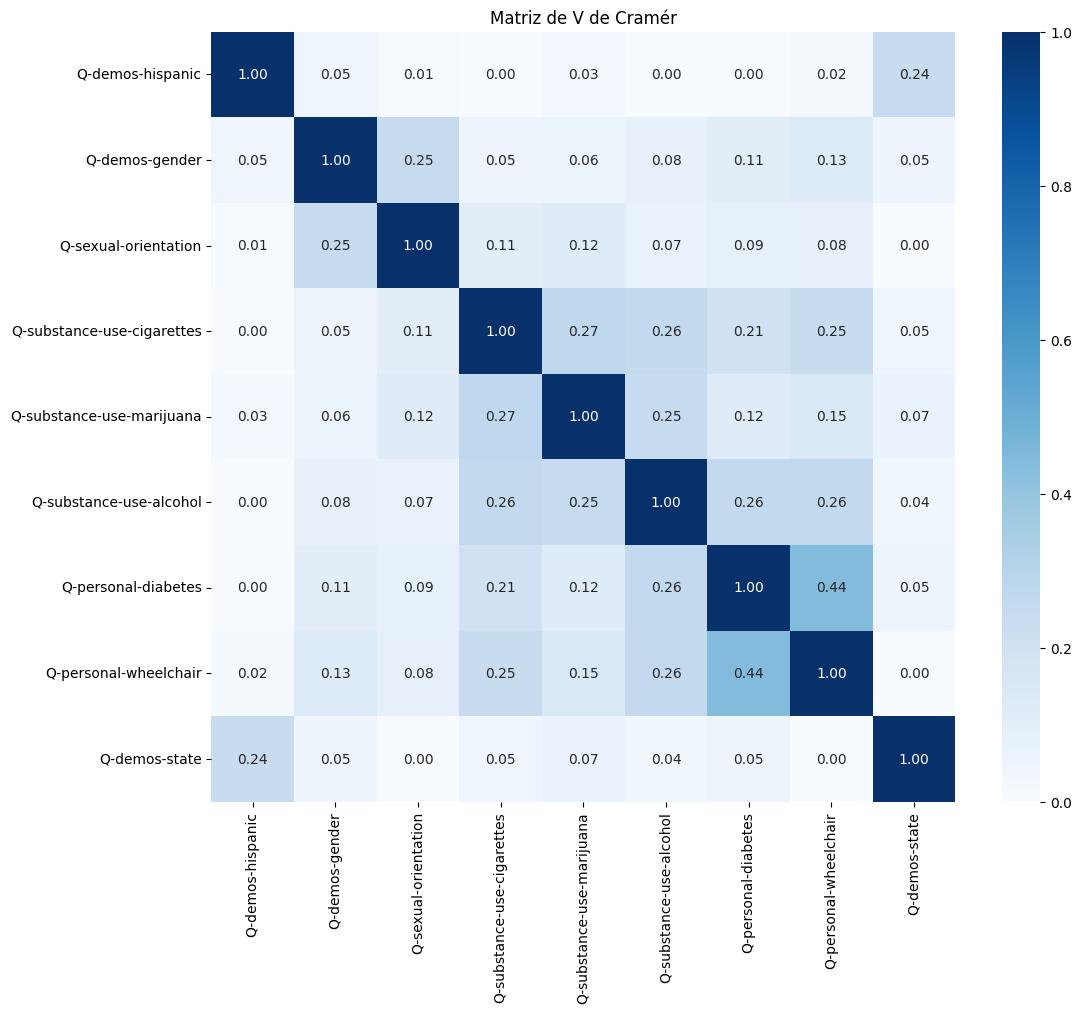

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de V de Cramér")
plt.show()

Se realiza el grafico en donde se justifica que entraran todas las variables ya que no a colinealidad entre ellas, como son tantas no entran todas, en la tabla de arriba se puede verificar 1 a 1

#### nominal vs ordinal

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tab = pd.crosstab(x, y)

    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = tab.shape

    phi2corr = max(0, phi2 - ((r - 1) * (k - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(rcorr - 1, kcorr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

In [19]:
df = data_survey2.copy()

for col in nominal_vars + ordinal_vars:
    df[col] = df[col].astype("category")

In [20]:
cramers_nom_ord = pd.DataFrame(
    np.nan,
    index=nominal_vars,
    columns=ordinal_vars
)

for nom in nominal_vars:
    for ord_ in ordinal_vars:
        pair = df[[nom, ord_]].dropna()
        cramers_nom_ord.loc[nom, ord_] = cramers_v(pair[nom], pair[ord_])

print(cramers_nom_ord.round(3))

                            Q-amazon-use-how-oft  Q-demos-age  \
Q-demos-hispanic                           0.017        0.138   
Q-demos-gender                             0.061        0.074   
Q-sexual-orientation                       0.024        0.179   
Q-substance-use-cigarettes                 0.025        0.055   
Q-substance-use-marijuana                  0.035        0.079   
Q-substance-use-alcohol                    0.039        0.038   
Q-personal-diabetes                        0.000        0.099   
Q-personal-wheelchair                      0.000        0.034   
Q-demos-state                              0.000        0.044   

                            Q-demos-education  Q-demos-income  \
Q-demos-hispanic                        0.053           0.052   
Q-demos-gender                          0.032           0.071   
Q-sexual-orientation                    0.071           0.121   
Q-substance-use-cigarettes              0.104           0.079   
Q-substance-use-marijuan

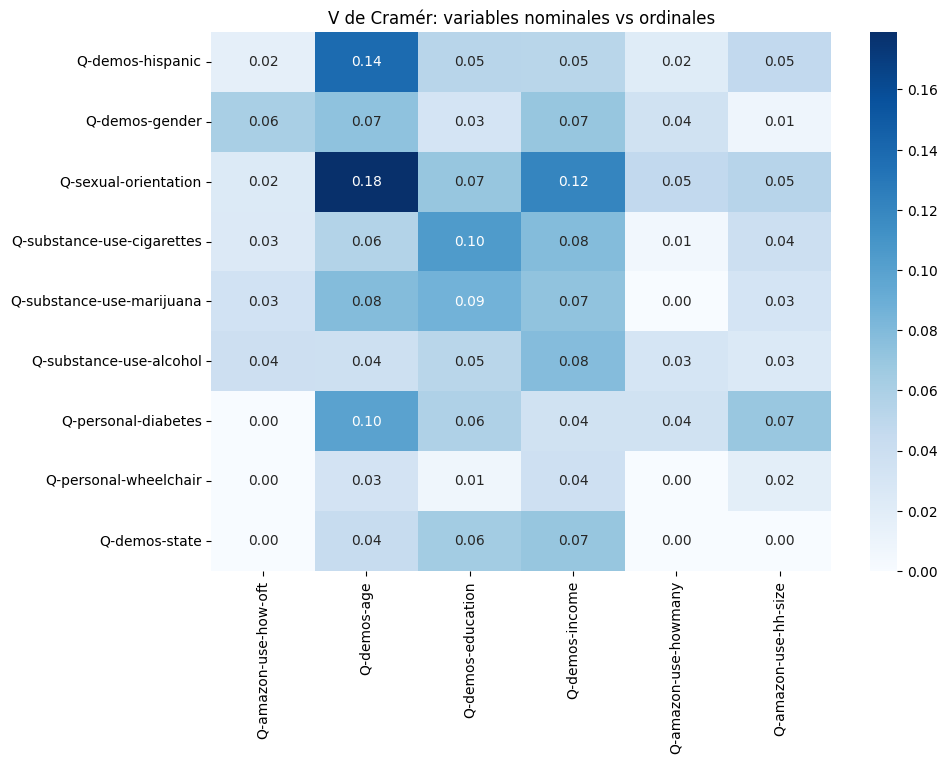

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(cramers_nom_ord.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("V de Cramér: variables nominales vs ordinales")
plt.show()

#### Spearman: ordinal vs ordinal

In [22]:
ordinal_orders = {
    "Q-amazon-use-how-oft": [
        "Rarely",
        "Sometimes",
        "Often"
    ],
    "Q-demos-age": [
        "18 - 24 years",
        "25 - 34 years",
        "35 - 44 years",
        "45 - 54 years",
        "55 - 64 years",
        "65 and older"
    ],
    "Q-demos-education": [
        "Less than high school",
        "High school",
        "Some college",
        "Bachelor's degree",
        "Graduate degree"
    ],
    "Q-demos-income": [
        "Less than $25,000",
        "$25,000 - $49,999",
        "$50,000 - $74,999",
        "$75,000 - $99,999",
        "$100,000 - $149,999",
        "$150,000 - $199,999",
        "$200,000 or more"
    ],
    "Q-amazon-use-howmany": [
        "1 (just me!)",
        "2",
        "3",
        "4+"
    ],
    "Q-amazon-use-hh-size": [
        "1",
        "2",
        "3",
        "4+"
    ]
}

In [23]:
import pandas as pd
import numpy as np

df_ord = data_survey2.copy()

for col, order in ordinal_orders.items():
    df_ord[col] = pd.Categorical(df_ord[col], categories=order, ordered=True)
    df_ord[col] = df_ord[col].cat.codes.replace(-1, np.nan)

In [24]:
from scipy.stats import spearmanr

spearman_matrix = pd.DataFrame(
    np.nan,
    index=ordinal_vars,
    columns=ordinal_vars
)

pvalue_matrix = pd.DataFrame(
    np.nan,
    index=ordinal_vars,
    columns=ordinal_vars
)

for i in ordinal_vars:
    for j in ordinal_vars:
        pair = df_ord[[i, j]].dropna()
        
        if i == j:
            spearman_matrix.loc[i, j] = 1.0
            pvalue_matrix.loc[i, j] = 0.0
        elif len(pair) > 1:
            rho, pval = spearmanr(pair[i], pair[j])
            spearman_matrix.loc[i, j] = rho
            pvalue_matrix.loc[i, j] = pval

C:\Users\workw\AppData\Local\Temp\ipykernel_15840\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_15840\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_15840\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_15840\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_15840\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pai

In [25]:
print("Matriz de Spearman:")
print(spearman_matrix.round(3))

print("\nMatriz de p-values:")
print(pvalue_matrix.round(4))

Matriz de Spearman:
                      Q-amazon-use-how-oft  Q-demos-age  Q-demos-education  \
Q-amazon-use-how-oft                   1.0          NaN                NaN   
Q-demos-age                            NaN        1.000                NaN   
Q-demos-education                      NaN          NaN                1.0   
Q-demos-income                         NaN        0.109                NaN   
Q-amazon-use-howmany                   NaN        0.032                NaN   
Q-amazon-use-hh-size                   NaN       -0.070                NaN   

                      Q-demos-income  Q-amazon-use-howmany  \
Q-amazon-use-how-oft             NaN                   NaN   
Q-demos-age                    0.109                 0.032   
Q-demos-education                NaN                   NaN   
Q-demos-income                 1.000                 0.155   
Q-amazon-use-howmany           0.155                 1.000   
Q-amazon-use-hh-size           0.075                 0.103   

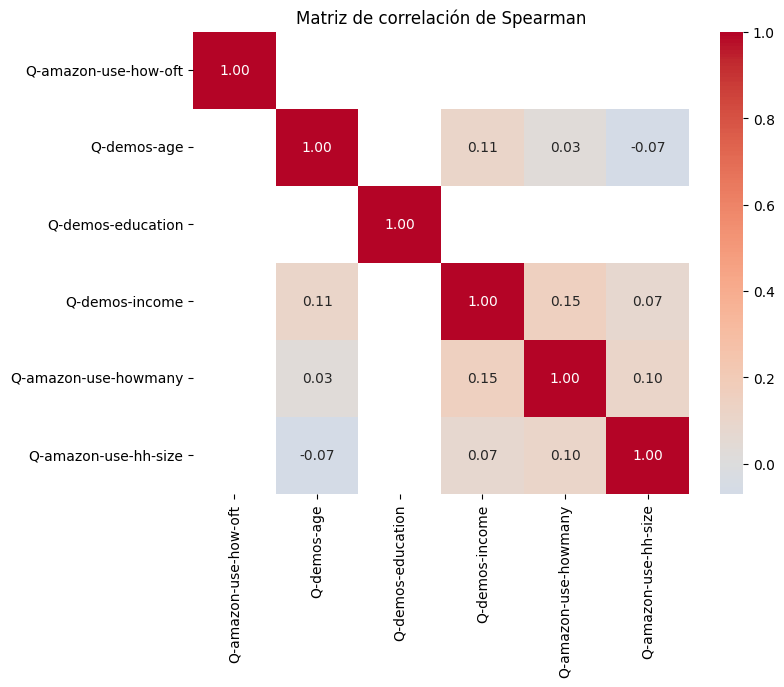

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de Spearman")
plt.show()

#### Seleccion multiple: nominal

In [27]:
race_col = "Q-demos-race"

race_dummies = (
    data_survey2[race_col]
    .fillna("")
    .str.get_dummies(sep=",")
)

race_dummies.columns = (
    race_dummies.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

race_dummies.columns = [f"race_{c}" for c in race_dummies.columns]

race_dummies.head()

,race_american_indian_native_american_or_alaska_native,race_asian,race_black_or_african_american,race_native_hawaiian_or_other_pacific_islander,race_other,race_white_or_caucasian
0,0,0,1,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

race_col = "Q-demos-race"

race_dummies = (
    data_survey2[race_col]
    .fillna("")
    .str.get_dummies(sep=",")
)

race_dummies.columns = (
    race_dummies.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

race_dummies.columns = [f"race_{c}" for c in race_dummies.columns]

race_dummies.head()

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = tab.shape

    phi2corr = max(0, phi2 - ((r - 1) * (k - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(rcorr - 1, kcorr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

results = []

for race_col_dummy in race_dummies.columns:
    for nominal_var in nominal_vars:
        pair = pd.DataFrame({
            "race_dummy": race_dummies[race_col_dummy],
            "nominal_var": data_survey2[nominal_var]
        }).dropna()

        v = cramers_v(pair["race_dummy"], pair["nominal_var"])
        
        results.append({
            "race_dummy": race_col_dummy,
            "nominal_variable": nominal_var,
            "cramers_v": v,
            "n_obs": len(pair)
        })

race_vs_nominal_df = pd.DataFrame(results)
race_vs_nominal_df = race_vs_nominal_df.sort_values("cramers_v", ascending=False)

print(race_vs_nominal_df)

threshold = 0.50

race_vs_nominal_high = race_vs_nominal_df[
    race_vs_nominal_df["cramers_v"] >= threshold
].sort_values("cramers_v", ascending=False)

print(race_vs_nominal_high)



                                           race_dummy  \
36                                         race_other   
17                                         race_asian   
53                            race_white_or_caucasian   
35     race_native_hawaiian_or_other_pacific_islander   
26                     race_black_or_african_american   
0   race_american_indian_native_american_or_alaska...   
44                                         race_other   
8   race_american_indian_native_american_or_alaska...   
45                            race_white_or_caucasian   
50                            race_white_or_caucasian   
10                                         race_asian   
48                            race_white_or_caucasian   
9                                          race_asian   
12                                         race_asian   
11                                         race_asian   
13                                         race_asian   
14                             

nominal_variable                                    Q-demos-gender  \
race_dummy                                                           
race_american_indian_native_american_or_alaska_...           0.050   
race_asian                                                   0.071   
race_black_or_african_american                               0.036   
race_native_hawaiian_or_other_pacific_islander               0.014   
race_other                                                   0.041   
race_white_or_caucasian                                      0.053   

nominal_variable                                    Q-demos-hispanic  \
race_dummy                                                             
race_american_indian_native_american_or_alaska_...             0.140   
race_asian                                                     0.068   
race_black_or_african_american                                 0.000   
race_native_hawaiian_or_other_pacific_islander                 0.005   
race_ot

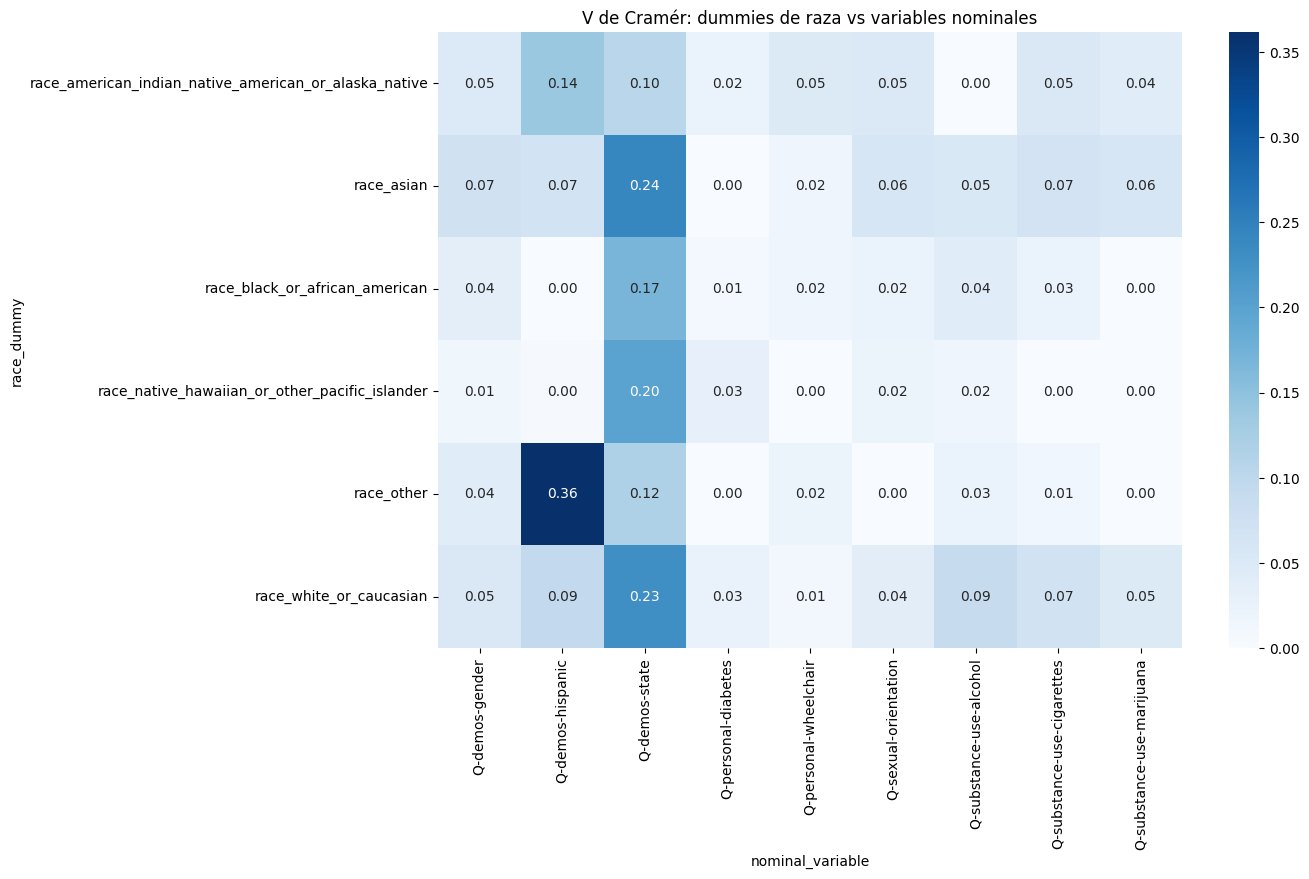

In [29]:
race_vs_nominal_matrix = race_vs_nominal_df.pivot(
    index="race_dummy",
    columns="nominal_variable",
    values="cramers_v"
)

print(race_vs_nominal_matrix.round(3))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(race_vs_nominal_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("V de Cramér: dummies de raza vs variables nominales")
plt.show()

#### nominal vs ordinal

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import norm, kendalltau

ordinal_orders = {
    "Q-amazon-use-how-oft": [
        "Rarely",
        "Sometimes",
        "Often"
    ],
    "Q-demos-age": [
        "18 - 24 years",
        "25 - 34 years",
        "35 - 44 years",
        "45 - 54 years",
        "55 - 64 years",
        "65 and older"
    ],
    "Q-demos-education": [
        "Less than high school",
        "High school",
        "Some college",
        "Bachelor's degree",
        "Graduate degree"
    ],
    "Q-demos-income": [
        "Less than $25,000",
        "$25,000 - $49,999",
        "$50,000 - $74,999",
        "$75,000 - $99,999",
        "$100,000 - $149,999",
        "$150,000 - $199,999",
        "$200,000 or more"
    ],
    "Q-amazon-use-howmany": [
        "1 (just me!)",
        "2",
        "3",
        "4+"
    ],
    "Q-amazon-use-hh-size": [
        "1",
        "2",
        "3",
        "4+"
    ]
}

ordinal_vars = list(ordinal_orders.keys())

df_ord = data_survey2.copy()

for col, order in ordinal_orders.items():
    df_ord[col] = pd.Categorical(df_ord[col], categories=order, ordered=True)

In [31]:
df_ord_codes = df_ord.copy()

for col in ordinal_vars:
    df_ord_codes[col] = df_ord_codes[col].cat.codes.replace(-1, np.nan)

In [32]:
race_col = "Q-demos-race"

race_dummies = (
    data_survey2[race_col]
    .fillna("")
    .str.get_dummies(sep=",")
)

race_dummies.columns = (
    race_dummies.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

race_dummies.columns = [f"race_{c}" for c in race_dummies.columns]

print(race_dummies.columns.tolist())
print(race_dummies.sum().sort_values(ascending=False))

['race_american_indian_native_american_or_alaska_native', 'race_asian', 'race_black_or_african_american', 'race_native_hawaiian_or_other_pacific_islander', 'race_other', 'race_white_or_caucasian']
race_white_or_caucasian                                  4133
race_asian                                                483
race_black_or_african_american                            448
race_other                                                135
race_american_indian_native_american_or_alaska_native     111
race_native_hawaiian_or_other_pacific_islander             19
dtype: int64


In [33]:
def cochran_armitage_test(binary, ordinal_codes):
    df = pd.DataFrame({
        "y": binary,
        "x": ordinal_codes
    }).dropna()

    df = df[df["y"].isin([0, 1])]

    if df.empty:
        return np.nan, np.nan

    tab = df.groupby("x")["y"].agg(["sum", "count"]).reset_index()
    tab.columns = ["score", "successes", "n_j"]

    if tab.shape[0] < 2:
        return np.nan, np.nan

    w = tab["score"].to_numpy(dtype=float)
    x_j = tab["successes"].to_numpy(dtype=float)
    n_j = tab["n_j"].to_numpy(dtype=float)

    n = n_j.sum()
    x_total = x_j.sum()

    if x_total == 0 or x_total == n:
        return np.nan, np.nan

    w_bar = np.sum(n_j * w) / n

    numerator = np.sum(w * (x_j - n_j * x_total / n))
    variance = (x_total * (n - x_total) / (n * (n - 1))) * np.sum(n_j * (w - w_bar) ** 2)

    if variance <= 0:
        return np.nan, np.nan

    z = numerator / np.sqrt(variance)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value

In [34]:
results = []

for race_dummy in race_dummies.columns:
    for ord_var in ordinal_vars:
        pair = pd.DataFrame({
            "race_dummy": race_dummies[race_dummy],
            "ord_code": df_ord_codes[ord_var]
        }).dropna()

        z_stat, p_trend = cochran_armitage_test(pair["race_dummy"], pair["ord_code"])
        tau_b, p_tau = kendalltau(pair["race_dummy"], pair["ord_code"])

        results.append({
            "race_dummy": race_dummy,
            "ordinal_variable": ord_var,
            "n_obs": len(pair),
            "cochran_armitage_z": z_stat,
            "cochran_armitage_p": p_trend,
            "kendall_tau_b": tau_b,
            "kendall_p": p_tau
        })

race_vs_ordinal_trend = pd.DataFrame(results)

print(race_vs_ordinal_trend.sort_values("cochran_armitage_p").head(20))

                                           race_dummy      ordinal_variable  \
31                            race_white_or_caucasian           Q-demos-age   
7                                          race_asian           Q-demos-age   
13                     race_black_or_african_american           Q-demos-age   
25                                         race_other           Q-demos-age   
35                            race_white_or_caucasian  Q-amazon-use-hh-size   
15                     race_black_or_african_american        Q-demos-income   
17                     race_black_or_african_american  Q-amazon-use-hh-size   
27                                         race_other        Q-demos-income   
11                                         race_asian  Q-amazon-use-hh-size   
9                                          race_asian        Q-demos-income   
3   race_american_indian_native_american_or_alaska...        Q-demos-income   
33                            race_white_or_caucasia

In [35]:
tau_matrix = race_vs_ordinal_trend.pivot(
    index="race_dummy",
    columns="ordinal_variable",
    values="kendall_tau_b"
)

print(tau_matrix.round(3))

ordinal_variable                                    Q-amazon-use-hh-size  \
race_dummy                                                                 
race_american_indian_native_american_or_alaska_...                -0.001   
race_asian                                                         0.046   
race_black_or_african_american                                     0.049   
race_native_hawaiian_or_other_pacific_islander                     0.006   
race_other                                                         0.029   
race_white_or_caucasian                                           -0.078   

ordinal_variable                                    Q-amazon-use-how-oft  \
race_dummy                                                                 
race_american_indian_native_american_or_alaska_...                   NaN   
race_asian                                                           NaN   
race_black_or_african_american                                       NaN   
race_native

In [36]:
p_matrix = race_vs_ordinal_trend.pivot(
    index="race_dummy",
    columns="ordinal_variable",
    values="cochran_armitage_p"
)

print(p_matrix.round(4))

ordinal_variable                                    Q-amazon-use-hh-size  \
race_dummy                                                                 
race_american_indian_native_american_or_alaska_...                0.9071   
race_asian                                                        0.0031   
race_black_or_african_american                                    0.0016   
race_native_hawaiian_or_other_pacific_islander                    0.6644   
race_other                                                        0.0614   
race_white_or_caucasian                                           0.0000   

ordinal_variable                                    Q-amazon-use-how-oft  \
race_dummy                                                                 
race_american_indian_native_american_or_alaska_...                   NaN   
race_asian                                                           NaN   
race_black_or_african_american                                       NaN   
race_native

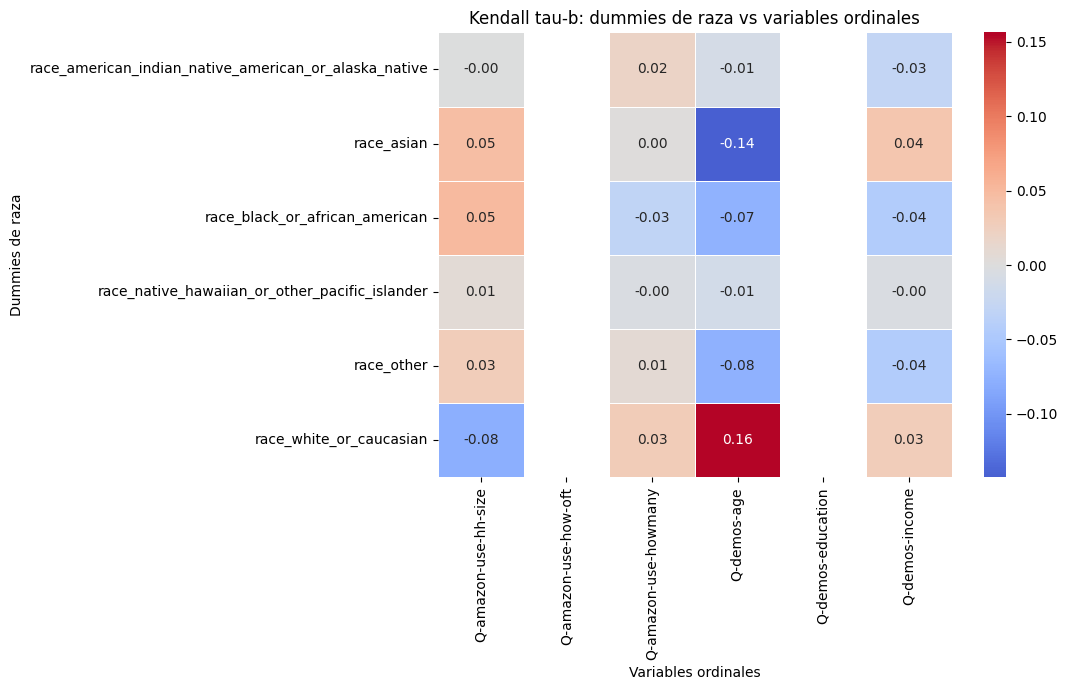

In [37]:
plt.figure(figsize=(11, 7))
sns.heatmap(
    tau_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Kendall tau-b: dummies de raza vs variables ordinales")
plt.xlabel("Variables ordinales")
plt.ylabel("Dummies de raza")
plt.tight_layout()
plt.show()

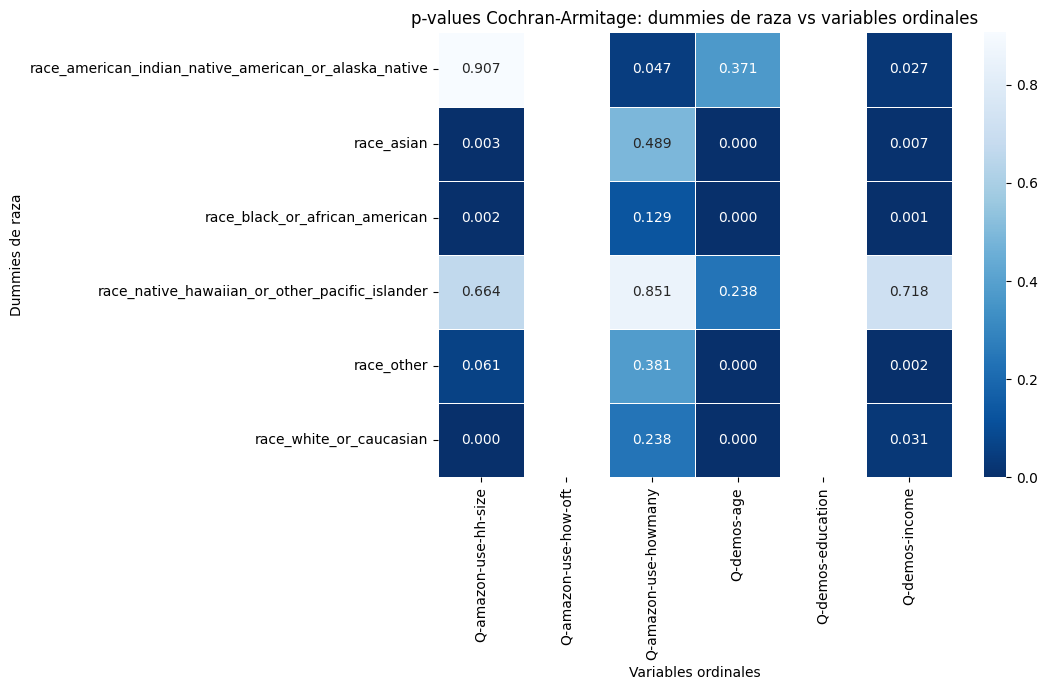

In [38]:
plt.figure(figsize=(11, 7))
sns.heatmap(
    p_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="Blues_r",
    linewidths=0.5
)
plt.title("p-values Cochran-Armitage: dummies de raza vs variables ordinales")
plt.xlabel("Variables ordinales")
plt.ylabel("Dummies de raza")
plt.tight_layout()
plt.show()

Por todo lo visto anteriormente ENTRARAN TODAS LAS VARIABLES DENTRO DEL MODELO YA QUE NO HAY COLINEALIDAD ENTRE ELLAS CON LOS TEST REALIZADOS

## 3. Exploracion de amazon-purchases.csv

### Quantity

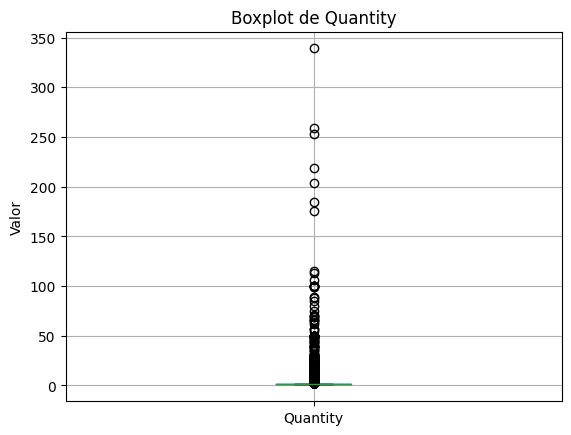

In [39]:
data_purchases[["Quantity"]].boxplot()
plt.title('Boxplot de Quantity')
plt.ylabel('Valor')
plt.show()

In [40]:
data_purchases['Quantity'].value_counts()

Quantity
1.0      1747647
2.0        76838
3.0        13953
4.0         6938
5.0         2211
          ...   
47.0           1
219.0          1
44.0           1
29.0           1
75.0           1
Name: count, Length: 69, dtype: int64

In [41]:
data_purchases['Quantity'].value_counts(normalize=True) * 100

Quantity
1.0      94.430807
2.0       4.151796
3.0       0.753924
4.0       0.374882
5.0       0.119467
           ...    
47.0      0.000054
219.0     0.000054
44.0      0.000054
29.0      0.000054
75.0      0.000054
Name: proportion, Length: 69, dtype: float64

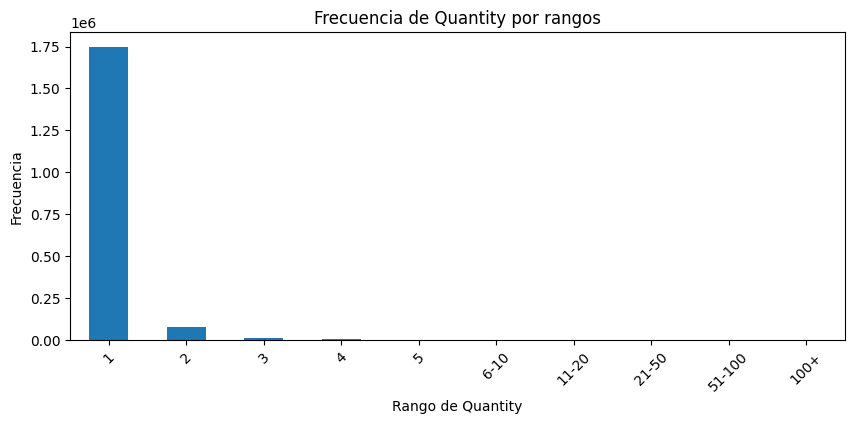

In [42]:
bins = [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, data_purchases['Quantity'].max()]
labels = ['1', '2', '3', '4', '5', '6-10', '11-20', '21-50', '51-100', '100+']

data_purchases['Quantity_rango'] = pd.cut(
    data_purchases['Quantity'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

data_purchases['Quantity_rango'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 4)
)

plt.title('Frecuencia de Quantity por rangos')
plt.xlabel('Rango de Quantity')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [43]:
data_purchases.describe()

,Purchase Price Per Unit,Quantity
count,1.850717e+06,1.850717e+06
mean,2.265906e+01,1.088636e+00
std,4.599967e+01,7.795341e-01
min,1.000000e-02,1.000000e+00
25%,8.470000e+00,1.000000e+00
50%,1.399000e+01,1.000000e+00
75%,2.375000e+01,1.000000e+00
max,6.398950e+03,3.390000e+02


### Purchase Price Per Unit

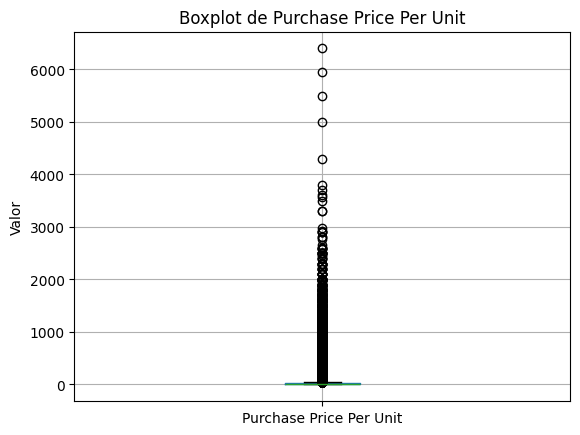

In [44]:
data_purchases[["Purchase Price Per Unit"]].boxplot()
plt.title('Boxplot de Purchase Price Per Unit')
plt.ylabel('Valor')
plt.show()

In [45]:
data_purchases['Purchase Price Per Unit'].value_counts()

Purchase Price Per Unit
9.99      56080
19.99     41049
14.99     37708
12.99     36835
7.99      32273
          ...  
215.70        1
212.03        1
255.74        1
219.70        1
100.94        1
Name: count, Length: 18282, dtype: int64

In [46]:
data_purchases['Purchase Price Per Unit'].value_counts(normalize=True) * 100

Purchase Price Per Unit
9.99      3.030177
19.99     2.218005
14.99     2.037481
12.99     1.990310
7.99      1.743811
            ...   
215.70    0.000054
212.03    0.000054
255.74    0.000054
219.70    0.000054
100.94    0.000054
Name: proportion, Length: 18282, dtype: float64

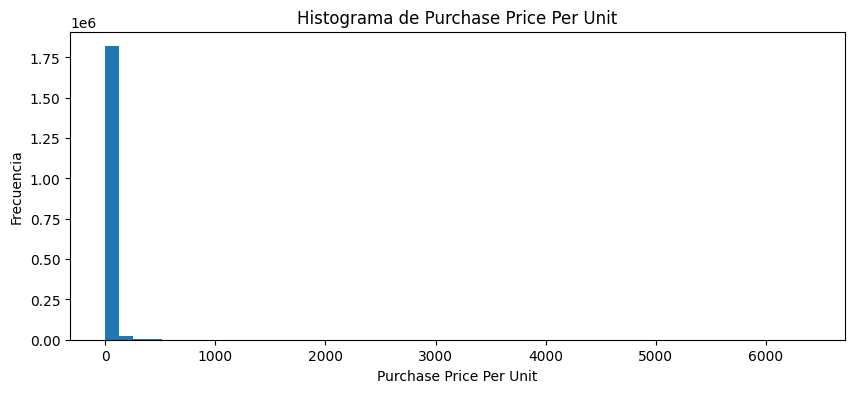

In [47]:
data_purchases['Purchase Price Per Unit'].plot(
    kind='hist',
    bins=50,
    figsize=(10, 4)
)

plt.title('Histograma de Purchase Price Per Unit')
plt.xlabel('Purchase Price Per Unit')
plt.ylabel('Frecuencia')
plt.show()

## 4. Analisis descriptivo univariado


## 5. Analisis descritivo bivariado